In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR NOTEBOOK.
import kagglehub
paultimothymooney_breast_histopathology_images_path = kagglehub.dataset_download('paultimothymooney/breast-histopathology-images')

print('Data source import complete.')

100%|██████████| 3.10G/3.10G [00:52<00:00, 63.2MB/s]

Extracting files...


Data source import complete.


In [ ]:
import os
import random
import shutil
import numpy as np
from PIL import Image
import tensorflow as tf

In [ ]:
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [ ]:
import os

base_path = "/kaggle/input"

print(os.listdir(base_path))

['datasets']


In [ ]:
base_path = "/kaggle/input/datasets/paultimothymooney/breast-histopathology-images"
data_path = base_path + "/IDC_regular_ps50_idx5"

In [ ]:
print(os.listdir(data_path)[:5])

['10295', '10304', '12868', '10274', '12818']


In [ ]:
#Data Sampling
import os
import random
import shutil

# Target directory where the sampled dataset will be stored
target_path = "/kaggle/working/dataset"

# Create folders for both classes (0 = Non-Cancer, 1 = Cancer)
# exist_ok=True ensures no error if folders already exist
os.makedirs(target_path + "/0", exist_ok=True)
os.makedirs(target_path + "/1", exist_ok=True)

# Limit number of images per class to create a balanced dataset
# This helps reduce training time and avoids class imbalance issues
LIMIT_PER_CLASS = 12000

# Dictionary to keep track of how many images have been copied per class
count = {"0": 0, "1": 0}

# Get list of all patient folders and shuffle them for randomness
# This ensures we don't pick images from only a few patients
patients = os.listdir(data_path)
random.shuffle(patients)

# Loop through each patient folder
for patient in patients:
    patient_path = os.path.join(data_path, patient)

    # Skip if not a valid directory
    if not os.path.isdir(patient_path):
        continue

    # Loop through both classes: 0 (non-cancer) and 1 (cancer)
    for label in ["0", "1"]:
        label_path = os.path.join(patient_path, label)

        # Check if the class folder exists inside the patient folder
        if os.path.exists(label_path):
            files = os.listdir(label_path)
            random.shuffle(files)

            for f in files:
                # Stop copying if we reached the required limit for this class
                if count[label] >= LIMIT_PER_CLASS:
                    continue

                # Copy image from original dataset to new balanced dataset
                shutil.copy(
                    os.path.join(label_path, f),
                    os.path.join(target_path, label, f)
                )

                # Increase count for this class
                count[label] += 1

    # Stop completely once both classes reach the limit
    if count["0"] >= LIMIT_PER_CLASS and count["1"] >= LIMIT_PER_CLASS:
        break

print("Done:", count)

Done: {'0': 12000, '1': 12000}


In [ ]:
#pre-processing image (removing corupted images)
from PIL import Image
import os

def clean(folder):
    removed = 0
    for label in ["0", "1"]:
        path = os.path.join(folder, label)
        for f in os.listdir(path):
            file_path = os.path.join(path, f)
            try:
                img = Image.open(file_path)
                img.verify()
            except:
                os.remove(file_path)
                removed += 1
    print("Removed:", removed)

clean("/kaggle/working/dataset")

Removed: 0


In [ ]:

from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Define image size and batch size
# IMG_SIZE resizes all images to a fixed dimension required by the model
# BATCH_SIZE defines how many images are processed at once during training
IMG_SIZE = 160
BATCH_SIZE = 32

# Create ImageDataGenerator for training data
# rescale=1./255 → normalizes pixel values from (0–255) to (0–1) for better learning
# validation_split=0.2 → splits 20% of data for validation
# rotation_range, zoom_range, horizontal_flip → data augmentation to increase diversity
# This helps reduce overfitting and improves generalization
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

# Create ImageDataGenerator for validation data
# Only rescaling is applied (no augmentation)
# This ensures validation data remains unchanged for fair evaluation
val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

# Load training data from directory
# flow_from_directory automatically reads images from class folders (0 and 1)
# target_size resizes images
# class_mode='binary' for two-class classification
# subset='training' selects the training portion (80%)
train_data = train_datagen.flow_from_directory(
    "/kaggle/working/dataset",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='training'
)

# Load validation data
# subset='validation' selects the remaining 20% of data
# shuffle=False is very important → keeps order fixed for correct evaluation later
val_data_full = val_datagen.flow_from_directory(
    "/kaggle/working/dataset",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=32,
    class_mode='binary',
    subset='validation',
    shuffle=False

)

Found 19200 images belonging to 2 classes.
Found 4800 images belonging to 2 classes.


In [ ]:
#MODEL 1 - CNN
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# This is a Convolutional Neural Network built from scratch
# It is used as a baseline model to understand how well a simple CNN performs
# on breast cancer image classification
model = Sequential([
    # First Convolution Layer
    # Applies 32 filters of size 3x3 to detect basic features like edges
    # input_shape defines the size of input images (160x160 with 3 color channels)
    Conv2D(32, (3,3), activation='relu', input_shape=(160,160,3)),
    MaxPooling2D(2,2), # MaxPooling reduces spatial dimensions (image size), Helps reduce computation and keeps important features


    # Second Convolution Layer
    # Increases filters to 64 → captures more complex patterns
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    # Third Convolution Layer
    # Further increases filters to 128 → captures deeper features
    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    # Flatten converts 3D feature maps into 1D vector
    # Required before passing to fully connected layers
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),

    # Output Layer
    # Single neuron with sigmoid activation for binary classification
    # Outputs probability (0 to 1) → cancer or non-cancer
    Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1775058649.793985      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1775058649.799898      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

# optimizer='adam' → Adaptive optimizer that adjusts learning rate automatically
# It is widely used because it converges faster and works well for most problems
# loss='binary_crossentropy' → suitable for binary classification (0 or 1)
# metrics=['accuracy'] → used to monitor overall performance during training
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Early Stopping Callback
# This stops training when validation loss stops improving
# monitor='val_loss' → tracks performance on validation data
# patience=2 → waits for 2 epochs before stopping if no improvement
# restore_best_weights=True → restores model weights from best epoch
# Helps prevent overfitting and saves training time
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

# Train the model
# train_data → training dataset
# validation_data → validation dataset for evaluation during training
# epochs=6 → maximum number of iterations over dataset
# steps_per_epoch=200 → limits number of batches per epoch (reduces training time)
# validation_steps=50 → limits validation batches (faster evaluation)
# callbacks=[early_stop] → applies early stopping during training
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=6,
    steps_per_epoch=200,
    validation_steps=50,
    callbacks=[early_stop]
)

Epoch 1/6
200/200 ━━━━━━━━━━━━━━━━━━━━ 43s 199ms/step - accuracy: 0.7488 - loss: 0.5339 - val_accuracy: 0.8462 - val_loss: 0.4162
Epoch 2/6
200/200 ━━━━━━━━━━━━━━━━━━━━ 39s 195ms/step - accuracy: 0.7975 - loss: 0.4603 - val_accuracy: 0.8831 - val_loss: 0.3864
Epoch 3/6
200/200 ━━━━━━━━━━━━━━━━━━━━ 38s 191ms/step - accuracy: 0.8090 - loss: 0.4330 - val_accuracy: 0.8669 - val_loss: 0.3929
Epoch 4/6
200/200 ━━━━━━━━━━━━━━━━━━━━ 38s 187ms/step - accuracy: 0.7782 - loss: 0.4899 - val_accuracy: 0.8288 - val_loss: 0.3984


In [ ]:
# Reset the validation generator
# This ensures that predictions start from the first image
val_data_full.reset()

# Generate predictions for all validation images
y_pred = model.predict(val_data_full, verbose=1)

# Convert probabilities into class labels (0 or 1)
# Threshold = 0.5 → if probability > 0.5 → class 1 (cancer), else class 0
y_pred = (y_pred > 0.5).astype(int)

y_true = val_data_full.classes

  3/150 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


150/150 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

print(confusion_matrix(y_true, y_pred))
print(classification_report(y_true, y_pred))

[[2020  380]
 [ 234 2166]]
              precision    recall  f1-score   support

           0       0.90      0.84      0.87      2400
           1       0.85      0.90      0.88      2400

    accuracy                           0.87      4800
   macro avg       0.87      0.87      0.87      4800
weighted avg       0.87      0.87      0.87      4800



In [ ]:
# MODEL 2 - MobileNet
# This is a pretrained Convolutional Neural Network used for transfer learning
# It is trained on the ImageNet dataset (millions of images), so it already
# knows how to extract general features like edges, textures, and shapes
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout

In [ ]:

base_model = MobileNetV2(
    # weights='imagenet' → loads pretrained weights from ImageNet
    # This allows the model to use previously learned features instead of training from scratch
    weights='imagenet',

    # include_top=False → removes the original classification layers
    # This is done because we want to add our own custom classifier
    # suited for binary classification (cancer vs non-cancer)
    include_top=False,

     # input_shape defines the size of input images
    # (160,160,3) → resized RGB images with 3 color channels
    input_shape=(160,160,3)
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
# base_model.layers[-30:] → selects the last 30 layers of the model
# These deeper layers contain more task-specific features
for layer in base_model.layers[-30:]:
    layer.trainable = True

In [ ]:
x = base_model.output

# GlobalAveragePooling2D converts 3D feature maps into a single 1D vector
# It takes the average of each feature map, reducing dimensions
# Helps reduce number of parameters and prevents overfitting
x = GlobalAveragePooling2D()(x)

# Fully connected layer to learn high-level patterns from extracted features
x = Dense(128, activation='relu')(x)

# Dropout randomly disables 50% of neurons during training
# Helps reduce overfitting and improves generalization
x = Dropout(0.5)(x)

# Output layer with sigmoid activation for binary classification
# Produces probability (0 to 1) → cancer or non-cancer
output = Dense(1, activation='sigmoid')(x)

# Output layer with sigmoid activation for binary classification
# Produces probability (0 to 1) → cancer or non-cancer
model_mobilenet = Model(inputs=base_model.input, outputs=output)

In [ ]:
from tensorflow.keras.optimizers import Adam

model_mobilenet.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

In [ ]:
history_finetune = model_mobilenet.fit(
    train_data,
    validation_data=val_data,
    epochs=3,
    steps_per_epoch=200,
    validation_steps=50,
    callbacks=[early_stop]
)


Epoch 1/3
200/200 ━━━━━━━━━━━━━━━━━━━━ 58s 208ms/step - accuracy: 0.6026 - loss: 0.7185 - val_accuracy: 0.6475 - val_loss: 0.6181
Epoch 2/3
200/200 ━━━━━━━━━━━━━━━━━━━━ 37s 184ms/step - accuracy: 0.7031 - loss: 0.5755 - val_accuracy: 0.6862 - val_loss: 0.5870
Epoch 3/3
200/200 ━━━━━━━━━━━━━━━━━━━━ 36s 180ms/step - accuracy: 0.7499 - loss: 0.5348 - val_accuracy: 0.7500 - val_loss: 0.5237


In [ ]:
val_data_full.reset()

y_pred_m = model_mobilenet.predict(val_data_full)
y_pred_m = (y_pred_m > 0.5).astype(int)

y_true = val_data_full.classes

150/150 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

print(confusion_matrix(y_true, y_pred_m))
print(classification_report(y_true, y_pred_m))

[[1291 1109]
 [  44 2356]]
              precision    recall  f1-score   support

           0       0.97      0.54      0.69      2400
           1       0.68      0.98      0.80      2400

    accuracy                           0.76      4800
   macro avg       0.82      0.76      0.75      4800
weighted avg       0.82      0.76      0.75      4800



In [ ]:
import matplotlib.pyplot as plt

def plot_history(history, title):

    # Accuracy plot
    plt.figure()
    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    plt.title(title + " - Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend(["Train", "Validation"])
    plt.show()

    # Loss plot
    plt.figure()
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title(title + " - Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend(["Train", "Validation"])
    plt.show()

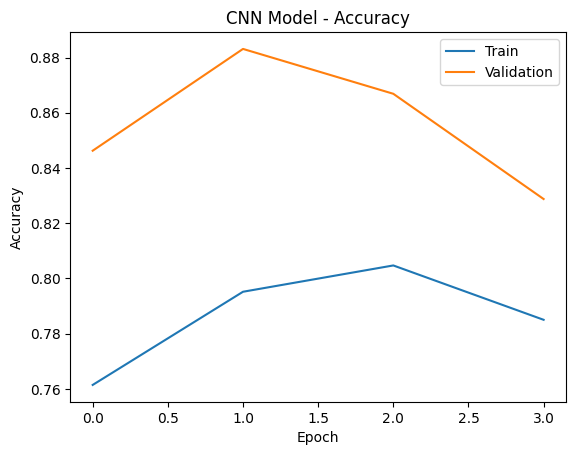

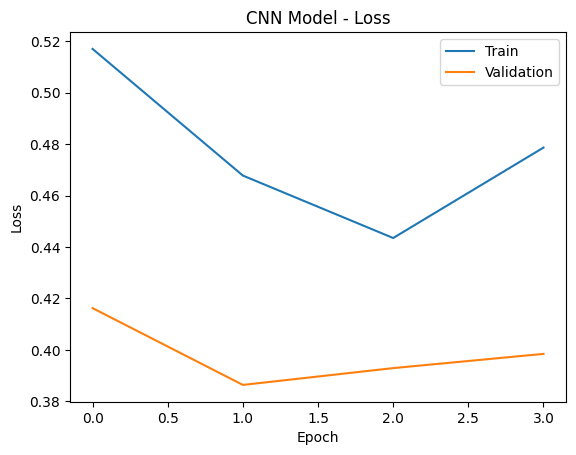

In [ ]:
# CNN Model - Interpretation of Graphs

# Accuracy:
# The training accuracy increases steadily, showing that the model is learning
# important features from the images. The validation accuracy peaks early
# (around Epoch 2) and then slightly decreases, indicating the start of overfitting.

# Loss:
# Training loss decreases continuously, which is expected as the model learns.
# However, validation loss starts increasing after a few epochs, confirming that
# the model begins to memorize training data instead of generalizing well.

# Conclusion:
# The CNN model performs well initially but shows signs of overfitting.
# Early stopping helps in selecting the best model before performance degrades.

plot_history(history, "CNN Model")

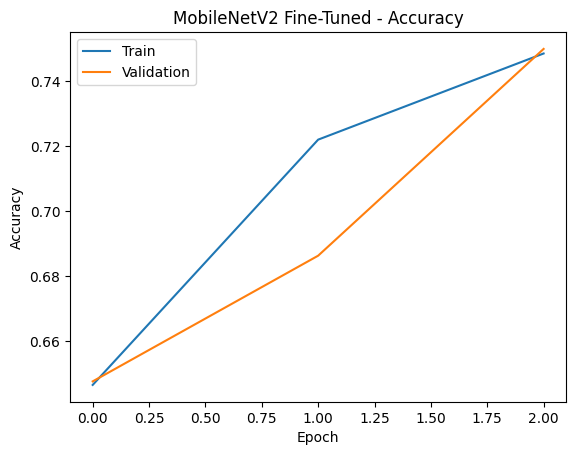

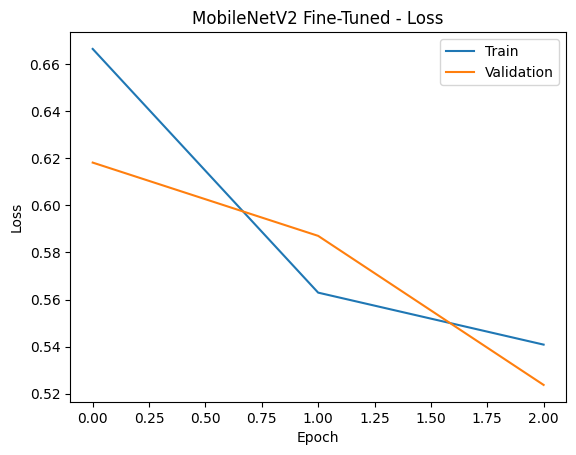

In [ ]:
# MobileNetV2 Fine-Tuned Model - Interpretation of Graphs

# Accuracy:
# The training accuracy improves gradually, but validation accuracy does not
# increase significantly and may fluctuate. This indicates that the model is
# not optimizing for overall accuracy.

# Loss:
# Training loss decreases, while validation loss may show fluctuations.
# This behavior suggests that the model is making trade-offs during learning.

# Conclusion:
# Although accuracy is lower compared to CNN, the fine-tuned model significantly
# improves cancer detection (recall). This demonstrates that accuracy alone is
# not sufficient, and recall is a more important metric in medical diagnosis.

plot_history(history_finetune, "MobileNetV2 Fine-Tuned")